# Visualisasi Data Multivariat Kategorik: Perpindahan Pasien Kesehatan

Notebook ini menganalisis pola perpindahan dan karakteristik pasien berdasarkan variabel kategorik seperti jenis kelamin, status BPJS, kelompok usia, jenis penyakit, jenis perawatan, kota asal, dan kota tujuan.

Fokus analisis:
- Melihat distribusi jumlah pasien berdasarkan kategori utama.
- Membandingkan rata-rata lama rawat antar kelompok pasien.
- Mengidentifikasi alur pasien berdasarkan status BPJS, penyakit, dan perpindahan kota.
- Menyajikan insight yang deskriptif tanpa menyimpulkan hubungan kausal.


## 1. Import Library dan Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

data = pd.read_excel("data_perpindahan_pasien_kesehatan.xlsx")
data.head()


,Tahun,Jenis_Kelamin,Usia_Kelompok,Rumah_Sakit_Asal,Rumah_Sakit_Tujuan,Kota_Asal,Kota_Tujuan,Jenis_Penyakit,Jenis_Perawatan,Lama_Rawat_Hari,BPJS_Status,Jumlah_Pasien
0,2024,Laki-laki,18-25,RSUD Bandung,RS Kariadi,Semarang,Surabaya,Hipertensi,ICU,2,Aktif,80
1,2023,Laki-laki,46-60,RSUP Fatmawati,RS Kariadi,Semarang,Yogyakarta,ISPA,Rawat Inap,9,Aktif,96
2,2023,Perempuan,46-60,RSUD Bandung,RSUD Makassar,Bandung,Denpasar,Diabetes,Rawat Inap,13,Aktif,94
3,2023,Perempuan,0-17,RSUP Fatmawati,RSUD Semarang,Jakarta,Yogyakarta,Demam Berdarah,Rawat Jalan,2,Nonaktif,49
4,2025,Perempuan,46-60,RSUP Sanglah,RSUD Semarang,Surabaya,Semarang,Demam Berdarah,Rawat Jalan,2,Nonaktif,85


## 2. Audit Struktur Data

Tahap ini memastikan dataset terbaca dengan benar, tidak memiliki missing value, dan kategori utama siap dipakai untuk visualisasi.


In [2]:
print(f"Jumlah baris: {data.shape[0]}")
print(f"Jumlah kolom: {data.shape[1]}")
print(f"Total pasien: {data['Jumlah_Pasien'].sum():,}")

display(data.dtypes.to_frame("Tipe Data"))
display(data.isna().sum().to_frame("Missing Value"))
display(data.nunique().to_frame("Jumlah Nilai Unik"))


Jumlah baris: 100
Jumlah kolom: 12
Total pasien: 5,566


,Tipe Data
Tahun,int64
Jenis_Kelamin,object
Usia_Kelompok,object
Rumah_Sakit_Asal,object
Rumah_Sakit_Tujuan,object
Kota_Asal,object
Kota_Tujuan,object
Jenis_Penyakit,object
Jenis_Perawatan,object
Lama_Rawat_Hari,int64


,Missing Value
Tahun,0
Jenis_Kelamin,0
Usia_Kelompok,0
Rumah_Sakit_Asal,0
Rumah_Sakit_Tujuan,0
Kota_Asal,0
Kota_Tujuan,0
Jenis_Penyakit,0
Jenis_Perawatan,0
Lama_Rawat_Hari,0


,Jumlah Nilai Unik
Tahun,3
Jenis_Kelamin,2
Usia_Kelompok,6
Rumah_Sakit_Asal,7
Rumah_Sakit_Tujuan,7
Kota_Asal,7
Kota_Tujuan,7
Jenis_Penyakit,7
Jenis_Perawatan,3
Lama_Rawat_Hari,14


In [3]:
kolom_kategorik = [
    "Jenis_Kelamin",
    "BPJS_Status",
    "Usia_Kelompok",
    "Rumah_Sakit_Asal",
    "Rumah_Sakit_Tujuan",
    "Kota_Asal",
    "Kota_Tujuan",
    "Jenis_Penyakit",
    "Jenis_Perawatan",
]

for kolom in kolom_kategorik:
    print(f"\n--- Nilai unik {kolom} ---")
    print(sorted(data[kolom].astype(str).unique()))



--- Nilai unik Jenis_Kelamin ---
['Laki-laki', 'Perempuan']

--- Nilai unik BPJS_Status ---
['Aktif', 'Nonaktif']

--- Nilai unik Usia_Kelompok ---
['0-17', '18-25', '26-35', '36-45', '46-60', '>60']

--- Nilai unik Rumah_Sakit_Asal ---
['RS Dr. Sardjito', 'RS Kariadi', 'RSUD Bandung', 'RSUD Makassar', 'RSUD Semarang', 'RSUP Fatmawati', 'RSUP Sanglah']

--- Nilai unik Rumah_Sakit_Tujuan ---
['RS Dr. Sardjito', 'RS Kariadi', 'RSUD Bandung', 'RSUD Makassar', 'RSUD Semarang', 'RSUP Fatmawati', 'RSUP Sanglah']

--- Nilai unik Kota_Asal ---
['Bandung', 'Denpasar', 'Jakarta', 'Makassar', 'Semarang', 'Surabaya', 'Yogyakarta']

--- Nilai unik Kota_Tujuan ---
['Bandung', 'Denpasar', 'Jakarta', 'Makassar', 'Semarang', 'Surabaya', 'Yogyakarta']

--- Nilai unik Jenis_Penyakit ---
['COVID-19', 'Demam Berdarah', 'Diabetes', 'Hipertensi', 'ISPA', 'Pneumonia', 'Stroke']

--- Nilai unik Jenis_Perawatan ---
['ICU', 'Rawat Inap', 'Rawat Jalan']


## 3. Ringkasan Awal Dataset

Ringkasan ini membantu memberi konteks sebelum masuk ke visualisasi multivariat.


In [4]:
ringkasan_penyakit = (
    data.groupby("Jenis_Penyakit", as_index=False)["Jumlah_Pasien"]
    .sum()
    .sort_values("Jumlah_Pasien", ascending=False)
)

ringkasan_tahun = (
    data.groupby("Tahun", as_index=False)["Jumlah_Pasien"]
    .sum()
    .sort_values("Tahun")
)

display(ringkasan_penyakit)
display(ringkasan_tahun)


,Jenis_Penyakit,Jumlah_Pasien
1,Demam Berdarah,899
5,Pneumonia,887
2,Diabetes,847
4,ISPA,839
3,Hipertensi,829
6,Stroke,695
0,COVID-19,570


,Tahun,Jumlah_Pasien
0,2023,1811
1,2024,1970
2,2025,1785


**Interpretasi singkat:**

Dataset berisi 100 baris observasi dengan total jumlah pasien yang direpresentasikan oleh kolom `Jumlah_Pasien`. Karena satu baris dapat mewakili lebih dari satu pasien, visualisasi berbasis volume pasien sebaiknya menggunakan agregasi `sum(Jumlah_Pasien)`, bukan hanya menghitung jumlah baris.


## 4. Mosaic Plot: Jenis Kelamin dan Status BPJS

Mosaic plot digunakan untuk melihat proporsi jumlah pasien berdasarkan kombinasi `Jenis_Kelamin` dan `BPJS_Status`.


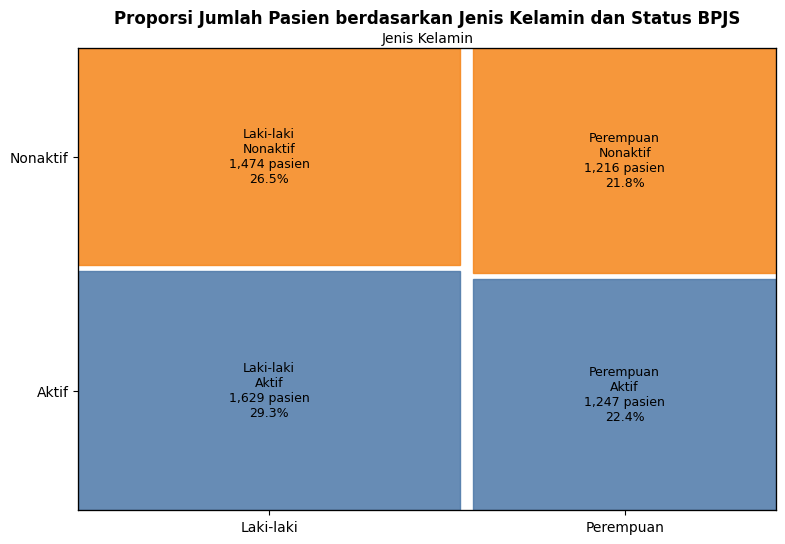

,Jenis_Kelamin,BPJS_Status,Jumlah_Pasien
0,Laki-laki,Aktif,1629
1,Laki-laki,Nonaktif,1474
2,Perempuan,Aktif,1247
3,Perempuan,Nonaktif,1216


In [5]:
from statsmodels.graphics.mosaicplot import mosaic

agg_bpjs_gender = (
    data.groupby(["Jenis_Kelamin", "BPJS_Status"], as_index=False)["Jumlah_Pasien"]
    .sum()
)

props = {
    (row["Jenis_Kelamin"], row["BPJS_Status"]): row["Jumlah_Pasien"]
    for _, row in agg_bpjs_gender.iterrows()
}
total_pasien = agg_bpjs_gender["Jumlah_Pasien"].sum()

fig, rects = mosaic(
    props,
    labelizer=lambda _: "",
    properties=lambda key: {
        "color": "#4C78A8" if key[1] == "Aktif" else "#F58518",
        "alpha": 0.85,
    },
    gap=0.02,
)

fig.set_size_inches(9, 6)
plt.title("Proporsi Jumlah Pasien berdasarkan Jenis Kelamin dan Status BPJS", fontweight="bold")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Status BPJS")

for key, (x, y, w, h) in rects.items():
    jumlah = props[key]
    persen = jumlah / total_pasien * 100
    plt.text(
        x + w / 2,
        y + h / 2,
        f"{key[0]}\n{key[1]}\n{jumlah:,} pasien\n{persen:.1f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="black",
    )

plt.show()
display(agg_bpjs_gender.sort_values("Jumlah_Pasien", ascending=False))


**Interpretasi:**

Distribusi pasien dapat dibandingkan lebih tepat dengan memakai total `Jumlah_Pasien`. Dari visual ini, kelompok pasien dengan BPJS aktif dan nonaktif terlihat menurut jenis kelamin, sehingga fokus insight berada pada proporsi pasien, bukan total lama rawat.


## 5. Grouped Bar Chart: Rata-rata Lama Rawat Berbobot

Karena setiap baris memiliki `Jumlah_Pasien`, rata-rata lama rawat dihitung sebagai weighted average:

`sum(Lama_Rawat_Hari * Jumlah_Pasien) / sum(Jumlah_Pasien)`


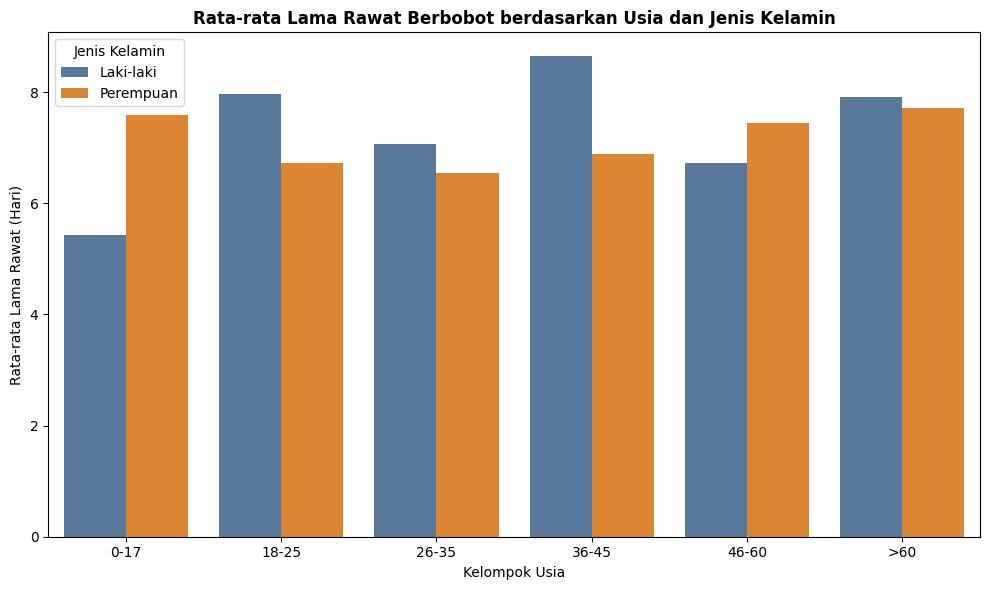

,Usia_Kelompok,Jenis_Kelamin,Total_Hari_Rawat,Jumlah_Pasien,Rata_Rata_Lama_Rawat
0,0-17,Laki-laki,2906,535,5.43
1,0-17,Perempuan,1884,248,7.60
2,18-25,Laki-laki,2652,333,7.96
3,18-25,Perempuan,4629,688,6.73
4,26-35,Laki-laki,3415,483,7.07
5,26-35,Perempuan,1795,274,6.55
6,36-45,Laki-laki,4901,567,8.64
7,36-45,Perempuan,3475,505,6.88
8,46-60,Laki-laki,2798,416,6.73
9,46-60,Perempuan,3346,449,7.45


In [6]:
urutan_usia = ["0-17", "18-25", "26-35", "36-45", "46-60", ">60"]

data["Usia_Kelompok"] = pd.Categorical(
    data["Usia_Kelompok"],
    categories=urutan_usia,
    ordered=True,
)

lama_rawat_usia_gender = (
    data.assign(Total_Hari_Rawat=data["Lama_Rawat_Hari"] * data["Jumlah_Pasien"])
    .groupby(["Usia_Kelompok", "Jenis_Kelamin"], observed=True, as_index=False)
    .agg(
        Total_Hari_Rawat=("Total_Hari_Rawat", "sum"),
        Jumlah_Pasien=("Jumlah_Pasien", "sum"),
    )
)
lama_rawat_usia_gender["Rata_Rata_Lama_Rawat"] = (
    lama_rawat_usia_gender["Total_Hari_Rawat"] / lama_rawat_usia_gender["Jumlah_Pasien"]
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=lama_rawat_usia_gender,
    x="Usia_Kelompok",
    y="Rata_Rata_Lama_Rawat",
    hue="Jenis_Kelamin",
    palette=["#4C78A8", "#F58518"],
)

plt.title("Rata-rata Lama Rawat Berbobot berdasarkan Usia dan Jenis Kelamin", fontweight="bold")
plt.xlabel("Kelompok Usia")
plt.ylabel("Rata-rata Lama Rawat (Hari)")
plt.legend(title="Jenis Kelamin")
plt.tight_layout()
plt.show()

display(lama_rawat_usia_gender.round({"Rata_Rata_Lama_Rawat": 2}))


**Interpretasi:**

Rata-rata lama rawat berbeda antar kelompok usia dan jenis kelamin, tetapi polanya tidak sepenuhnya naik secara linear mengikuti usia. Beberapa kelompok usia yang lebih tua memiliki durasi rawat relatif tinggi, namun terdapat variasi antar jenis kelamin dan kelompok umur. Karena itu, insight yang lebih aman adalah adanya perbedaan durasi rawat antar segmen pasien, bukan kesimpulan kausal bahwa usia selalu meningkatkan lama rawat.


## 6. Treemap: Volume Pasien dan Rata-rata Lama Rawat

Pada treemap ini, ukuran kotak menunjukkan `Jumlah_Pasien`, sedangkan warna menunjukkan rata-rata lama rawat berbobot. Dengan begitu, area menggambarkan volume pasien dan warna menggambarkan intensitas durasi rawat.


In [7]:
import plotly.express as px
from IPython.display import HTML

treemap_data = (
    data.assign(Total_Hari_Rawat=data["Lama_Rawat_Hari"] * data["Jumlah_Pasien"])
    .groupby(["Usia_Kelompok", "Jenis_Kelamin", "Jenis_Penyakit"], observed=True, as_index=False)
    .agg(
        Jumlah_Pasien=("Jumlah_Pasien", "sum"),
        Total_Hari_Rawat=("Total_Hari_Rawat", "sum"),
    )
)
treemap_data["Rata_Rata_Lama_Rawat"] = (
    treemap_data["Total_Hari_Rawat"] / treemap_data["Jumlah_Pasien"]
)

fig = px.treemap(
    treemap_data,
    path=["Usia_Kelompok", "Jenis_Kelamin", "Jenis_Penyakit"],
    values="Jumlah_Pasien",
    color="Rata_Rata_Lama_Rawat",
    color_continuous_scale="Blues",
    title="Jumlah Pasien dan Rata-rata Lama Rawat berdasarkan Usia, Jenis Kelamin, dan Penyakit",
    hover_data={
        "Jumlah_Pasien": ":,",
        "Rata_Rata_Lama_Rawat": ":.2f",
        "Total_Hari_Rawat": False,
    },
)

HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))


**Interpretasi:**

Treemap membantu membedakan dua hal sekaligus: segmen dengan volume pasien besar dan segmen dengan rata-rata lama rawat tinggi. Segmen berukuran besar tidak selalu berarti memiliki durasi rawat paling lama, sehingga pembacaan insight perlu melihat kombinasi area dan warna.


## 7. Sankey Diagram: Alur Jenis Kelamin, BPJS, dan Penyakit

Sankey diagram menampilkan alur jumlah pasien dari `Jenis_Kelamin` ke `BPJS_Status`, lalu ke `Jenis_Penyakit`. Nilai alur dihitung menggunakan total `Jumlah_Pasien`.


In [8]:
import plotly.graph_objects as go
from IPython.display import HTML

sankey_data = (
    data.groupby(["Jenis_Kelamin", "BPJS_Status", "Jenis_Penyakit"], as_index=False)["Jumlah_Pasien"]
    .sum()
)

labels = list(pd.unique(sankey_data[["Jenis_Kelamin", "BPJS_Status", "Jenis_Penyakit"]].values.ravel()))
label_to_index = {label: idx for idx, label in enumerate(labels)}

gender_bpjs = (
    sankey_data.groupby(["Jenis_Kelamin", "BPJS_Status"], as_index=False)["Jumlah_Pasien"]
    .sum()
)
bpjs_penyakit = (
    sankey_data.groupby(["BPJS_Status", "Jenis_Penyakit"], as_index=False)["Jumlah_Pasien"]
    .sum()
)

source_all = (
    gender_bpjs["Jenis_Kelamin"].map(label_to_index).tolist()
    + bpjs_penyakit["BPJS_Status"].map(label_to_index).tolist()
)
target_all = (
    gender_bpjs["BPJS_Status"].map(label_to_index).tolist()
    + bpjs_penyakit["Jenis_Penyakit"].map(label_to_index).tolist()
)
value_all = (
    gender_bpjs["Jumlah_Pasien"].tolist()
    + bpjs_penyakit["Jumlah_Pasien"].tolist()
)

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=18,
                thickness=18,
                line=dict(color="black", width=0.4),
                label=labels,
            ),
            link=dict(
                source=source_all,
                target=target_all,
                value=value_all,
            ),
        )
    ]
)

fig.update_layout(
    title_text="Alur Jumlah Pasien berdasarkan Jenis Kelamin, Status BPJS, dan Penyakit",
    font_size=11,
)
HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))


**Interpretasi:**

Alur terbesar menunjukkan segmen pasien dengan volume terbanyak setelah mempertimbangkan `Jumlah_Pasien`. Visual ini cocok untuk membaca distribusi pasien dari jenis kelamin menuju status BPJS, lalu ke jenis penyakit. Karena diagram ini berbasis agregasi pasien, ketebalan garis dapat dibaca sebagai volume pasien, bukan sekadar jumlah kombinasi baris di dataset.


## 8. Chord Diagram: Perpindahan Pasien Antar Kota

Chord diagram digunakan untuk melihat jaringan perpindahan pasien dari kota asal ke kota tujuan. Data terlebih dahulu diagregasi berdasarkan total `Jumlah_Pasien` per pasangan kota.


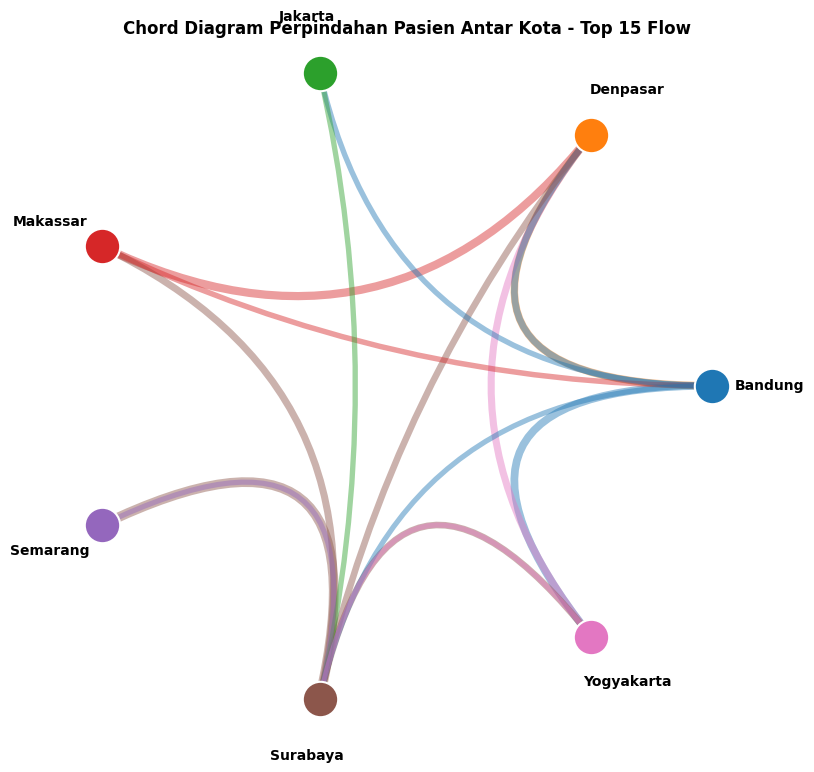

In [9]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch

flow_kota = (
    data.groupby(["Kota_Asal", "Kota_Tujuan"], as_index=False)["Jumlah_Pasien"]
    .sum()
    .rename(columns={
        "Kota_Asal": "source",
        "Kota_Tujuan": "target",
        "Jumlah_Pasien": "value",
    })
    .sort_values("value", ascending=False)
)

# Batasi flow terbesar agar chord tetap mudah dibaca.
top_flow_kota = flow_kota.head(15).copy()
nodes = sorted(set(top_flow_kota["source"]).union(set(top_flow_kota["target"])))

angle = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
pos = {
    node: np.array([np.cos(a), np.sin(a)])
    for node, a in zip(nodes, angle)
}
colors = dict(zip(nodes, sns.color_palette("tab10", len(nodes))))
max_value = top_flow_kota["value"].max()

fig, ax = plt.subplots(figsize=(8, 8))

for _, row in top_flow_kota.iterrows():
    source = row["source"]
    target = row["target"]
    value = row["value"]
    p0 = pos[source]
    p1 = pos[target]

    path = Path(
        [p0, np.array([0, 0]), p1],
        [Path.MOVETO, Path.CURVE3, Path.CURVE3],
    )
    patch = PathPatch(
        path,
        facecolor="none",
        edgecolor=colors[source],
        linewidth=1 + 6 * (value / max_value),
        alpha=0.45,
    )
    ax.add_patch(patch)

for node, xy in pos.items():
    ax.scatter(*xy, s=650, color=colors[node], edgecolor="white", linewidth=1.5, zorder=3)
    label_xy = xy * 1.18
    ax.text(
        label_xy[0],
        label_xy[1],
        node,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("Chord Diagram Perpindahan Pasien Antar Kota - Top 15 Flow", fontweight="bold")
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()


In [10]:
display(flow_kota.head(10))


,source,target,value
29,Surabaya,Semarang,369
16,Makassar,Denpasar,302
5,Bandung,Yogyakarta,282
6,Denpasar,Bandung,271
32,Yogyakarta,Denpasar,252
28,Surabaya,Makassar,249
0,Bandung,Denpasar,236
30,Surabaya,Yogyakarta,232
26,Surabaya,Denpasar,228
15,Makassar,Bandung,181


**Interpretasi:**

Chord diagram menunjukkan hubungan perpindahan pasien antar kota. Ketebalan hubungan merepresentasikan total pasien, sehingga pasangan kota dengan nilai terbesar dapat dilihat sebagai arus perpindahan paling dominan. Berdasarkan agregasi data, beberapa flow terbesar muncul pada rute seperti Surabaya ke Semarang, Makassar ke Denpasar, dan Bandung ke Yogyakarta.


## 9. Kesimpulan

Beberapa insight utama dari analisis:

- Dataset memiliki total pasien yang perlu dianalisis menggunakan `Jumlah_Pasien` sebagai bobot atau ukuran volume.
- Distribusi pasien berdasarkan jenis kelamin dan status BPJS lebih tepat dibaca dari total jumlah pasien, bukan dari total lama rawat.
- Rata-rata lama rawat berbeda antar kelompok usia dan jenis kelamin, tetapi tidak menunjukkan pola linear yang mutlak.
- Treemap menunjukkan bahwa segmen dengan volume pasien besar tidak selalu memiliki rata-rata lama rawat tertinggi.
- Sankey diagram membantu membaca alur pasien dari jenis kelamin ke BPJS dan penyakit.
- Chord diagram menunjukkan perpindahan pasien antar kota, dengan beberapa rute memiliki volume pasien lebih besar dibanding rute lain.

Rekomendasi analisis lanjutan:
- Bandingkan pola antar tahun untuk melihat perubahan volume pasien dari 2023 sampai 2025.
- Tambahkan analisis berdasarkan `Jenis_Perawatan` untuk membedakan rawat jalan, rawat inap, dan ICU.
- Jika tersedia data biaya atau kapasitas rumah sakit, analisis dapat diperluas ke kebutuhan sumber daya layanan kesehatan.
